### Extraxtion et transformation du data en dataframe pour faire des analyses

In [2]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
BASE_DIR = os.getcwd()

# 2. On construit le chemin vers 'data' de manière robuste
# Cela fonctionnera même sous Windows ou Linux (gestion des slashs / vs \)
data_path = os.path.join(BASE_DIR, "../data")

print(f"Recherche des fichiers dans : {data_path}")

def build_ner_dataset_v2(directory_path):
    # Ce pattern capture les tags même s'il y a des retours à la ligne ou des espaces variés
    ner_pattern = r"<(\w+)>\s*(.*?)\s*</\1>"
    
    data_list = []
    
    # Vérifier si le dossier existe
    if not os.path.exists(directory_path):
        print(f"Erreur : Le dossier '{directory_path}' est introuvable.")
        return None

    for filename in os.listdir(directory_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory_path, filename)
            
            with open(file_path, 'r', encoding='utf-8') as f:
                for line_num, line in enumerate(f, 1):
                    line = line.strip()
                    if not line:
                        continue
                    
                    # Déterminer le script (Arabe vs Arabizi)
                    # On cherche la présence de caractères arabes (\u0600-\u06FF)
                    has_arabic = bool(re.search(r'[\u0600-\u06FF]', line))
                    script_type = "Arabic" if has_arabic else "Arabizi"
                    
                    # Trouver toutes les entités dans la ligne
                    matches = re.findall(ner_pattern, line)
                    
                    for tag, value in matches:
                        data_list.append({
                            "file": filename,
                            "line_id": line_num,
                            "entity_value": value.strip(),
                            "label": tag,
                            "script": script_type
                        })
    
    df = pd.DataFrame(data_list)
    return df

# Pour l'utiliser :
# df = build_ner_dataset_v2("data/")
# print(df.head())

Recherche des fichiers dans : d:\3D Objects\IID2\Data Mining\projet-NER-darija\notebook\../data


In [3]:
df1 = build_ner_dataset_v2(f"{data_path}\\raw_annoted\\chatgpt_ner")
df2 = build_ner_dataset_v2(f"{data_path}\\raw_annoted\\Gemini_NER_data")

In [4]:
print(f"shape de prepier dataframe chatgpt : {df1.shape}")
print(f"shape de prepier dataframe Gemini : {df2.shape}")

shape de prepier dataframe chatgpt : (12224, 5)
shape de prepier dataframe Gemini : (130561, 5)


In [5]:
df1.head(20)

,file,line_id,entity_value,label,script
0,Akdital NER Tagging.txt,2,أكديطال,ORG,Arabic
1,Akdital NER Tagging.txt,2,ليزاكسون,CARDINAL,Arabic
2,Akdital NER Tagging.txt,2,ليزاكسون,CARDINAL,Arabic
3,Akdital NER Tagging.txt,2,أكديطال,ORG,Arabic
4,Akdital NER Tagging.txt,2,البورصة,GOV,Arabic
5,Akdital NER Tagging.txt,2,الدولة,GOV_AGG,Arabic
6,Akdital NER Tagging.txt,2,نهار الاثنين,DATE,Arabic
7,Akdital NER Tagging.txt,3,أكديطال,ORG,Arabic
8,Akdital NER Tagging.txt,3,ليزاكسون,CARDINAL,Arabic
9,Akdital NER Tagging.txt,3,ليزاكسون,CARDINAL,Arabic


In [6]:
df1.tail()

,file,line_id,entity_value,label,script
12219,والي بنك المغرب.txt,28,lmaghrib,GPE,Arabizi
12220,والي بنك المغرب.txt,28,Turkia,GPE,Arabizi
12221,والي بنك المغرب.txt,28,lmaghrib,GPE,Arabizi
12222,والي بنك المغرب.txt,28,lmaghrib,GPE,Arabizi
12223,والي بنك المغرب.txt,28,Turkia,GPE,Arabizi


In [7]:
df2.head()

,file,line_id,entity_value,label,script
0,"ADHD_ Symptoms, Diagnosis, and Treatment - 98.txt",5,عام 2022,DATE,Arabic
1,"ADHD_ Symptoms, Diagnosis, and Treatment - 98.txt",5,5 مليون,CARDINAL,Arabic
2,"ADHD_ Symptoms, Diagnosis, and Treatment - 98.txt",5,2,CARDINAL,Arabic
3,"ADHD_ Symptoms, Diagnosis, and Treatment - 98.txt",5,الجمعية الأمريكية للطب النفسي,ORG,Arabic
4,"ADHD_ Symptoms, Diagnosis, and Treatment - 98.txt",5,العلماء,PERSON_AGG,Arabic


In [8]:
df2.tail()

,file,line_id,entity_value,label,script
130556,مصر والمغرب_ مقارنة اقتصادية - 135.txt,132,tmn snin,DATE,Arabic
130557,مصر والمغرب_ مقارنة اقتصادية - 135.txt,132,lbanka,ORG,Arabic
130558,مصر والمغرب_ مقارنة اقتصادية - 135.txt,132,lcontra,LAW,Arabic
130559,مصر والمغرب_ مقارنة اقتصادية - 135.txt,132,lbanka,ORG,Arabic
130560,مصر والمغرب_ مقارنة اقتصادية - 135.txt,132,licontat,ORG,Arabic


In [9]:
df = pd.concat([df1,df2],ignore_index=True)

In [10]:
df.shape

(142785, 5)

In [11]:
df['label'].value_counts()

label
GPE                33186
CARDINAL           20740
DATE               15192
ORG                12828
EVENT_AGG          12153
NORP                7346
LOC                 5862
PERSON_AGG          5083
PERSON              3651
GOV_AGG             3462
GOV                 3461
WORK_OF_ART         2499
LAW                 2446
ORG_AGG             2314
EVENT               2251
ORDINAL             1983
MEDIA_AGG           1530
ENTITY_TYPE_AGG     1394
LANGUAGE            1370
MEDIA               1014
ECONOMY_AGG          786
ITEM                 550
CURRENCY             282
NORP_AGG             186
LOC_AGG              172
GPE_AGG              140
PERCENT              122
ENTITY_TYPE          112
CURRENCY_AGG         110
CARDINAL_AGG         106
WORK_OF_ART_AGG       86
RESOURCE              66
LANGUAGE_AGG          62
PRODUCT               56
LAW_AGG               40
ECON_INDICATOR        36
ECONOMIC_TERM         25
PERSON_AGG_AGG        24
LOCATION              11
MISC               

C:\Users\amine\AppData\Local\Temp\ipykernel_19420\2028129549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=order, palette='viridis')


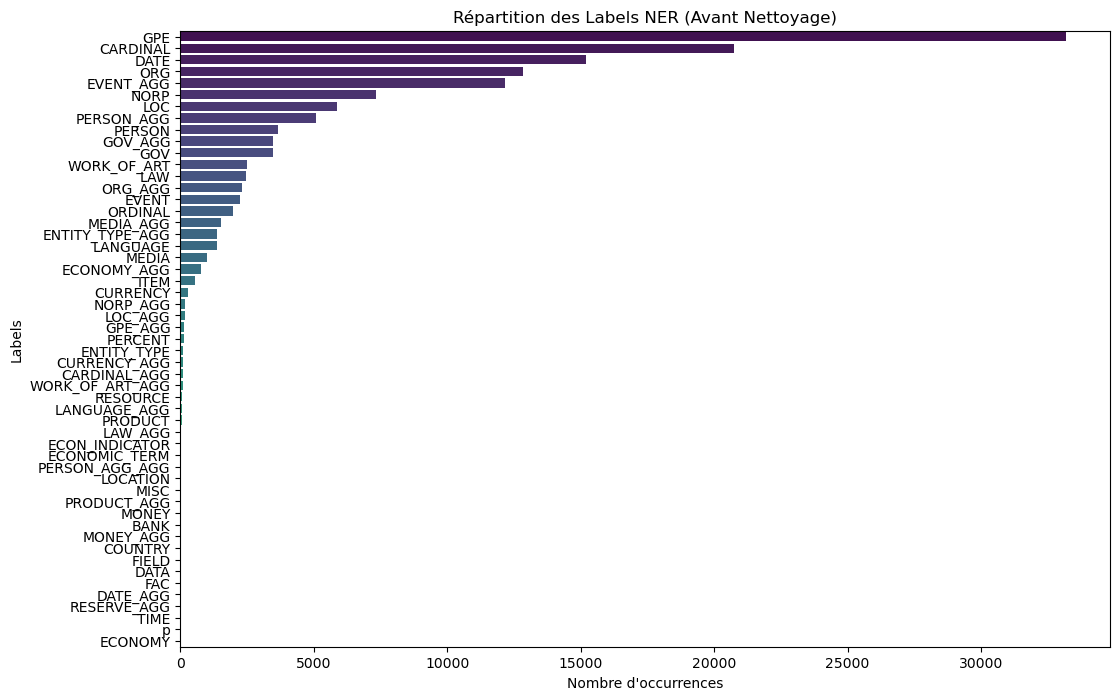

In [12]:
plt.figure(figsize=(12, 8))
order = df['label'].value_counts().index
sns.countplot(data=df, y='label', order=order, palette='viridis')
plt.title('Répartition des Labels NER (Avant Nettoyage)')
plt.xlabel('Nombre d\'occurrences')
plt.ylabel('Labels')
plt.show()


Je vois qu'il ya des entity n'ont pas d'importance et il faut les traiter par exemple :
BANK , TIME ,ECONOMY .. ils sont soit déja une entity qui a le meme reference comme ORG ,DATE ou des entity faut les supp comme FAC FIELD
  
  
il y a aussi des entity faut les fusionner par exemple ORG_AGG pour notre model nous donne plus bons résultats et doubler la puissance

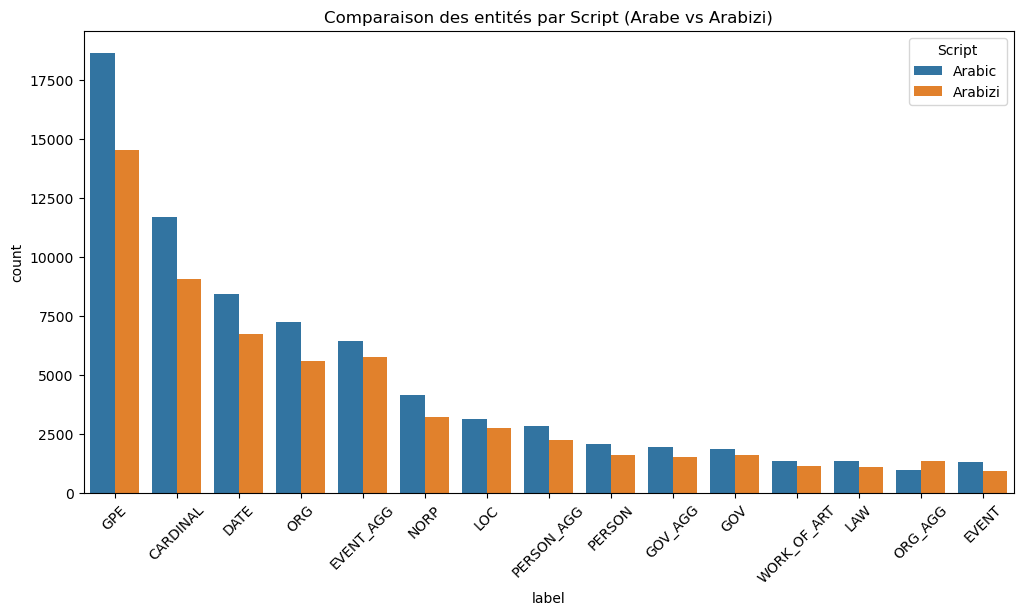

In [13]:
plt.figure(figsize=(12, 6))
# On prend le top 15 pour la lisibilité
top_labels = df['label'].value_counts().head(15).index
df_sub = df[df['label'].isin(top_labels)]

sns.countplot(data=df_sub, x='label', hue='script', order=top_labels)
plt.xticks(rotation=45)
plt.title('Comparaison des entités par Script (Arabe vs Arabizi)')
plt.legend(title='Script')
plt.show()

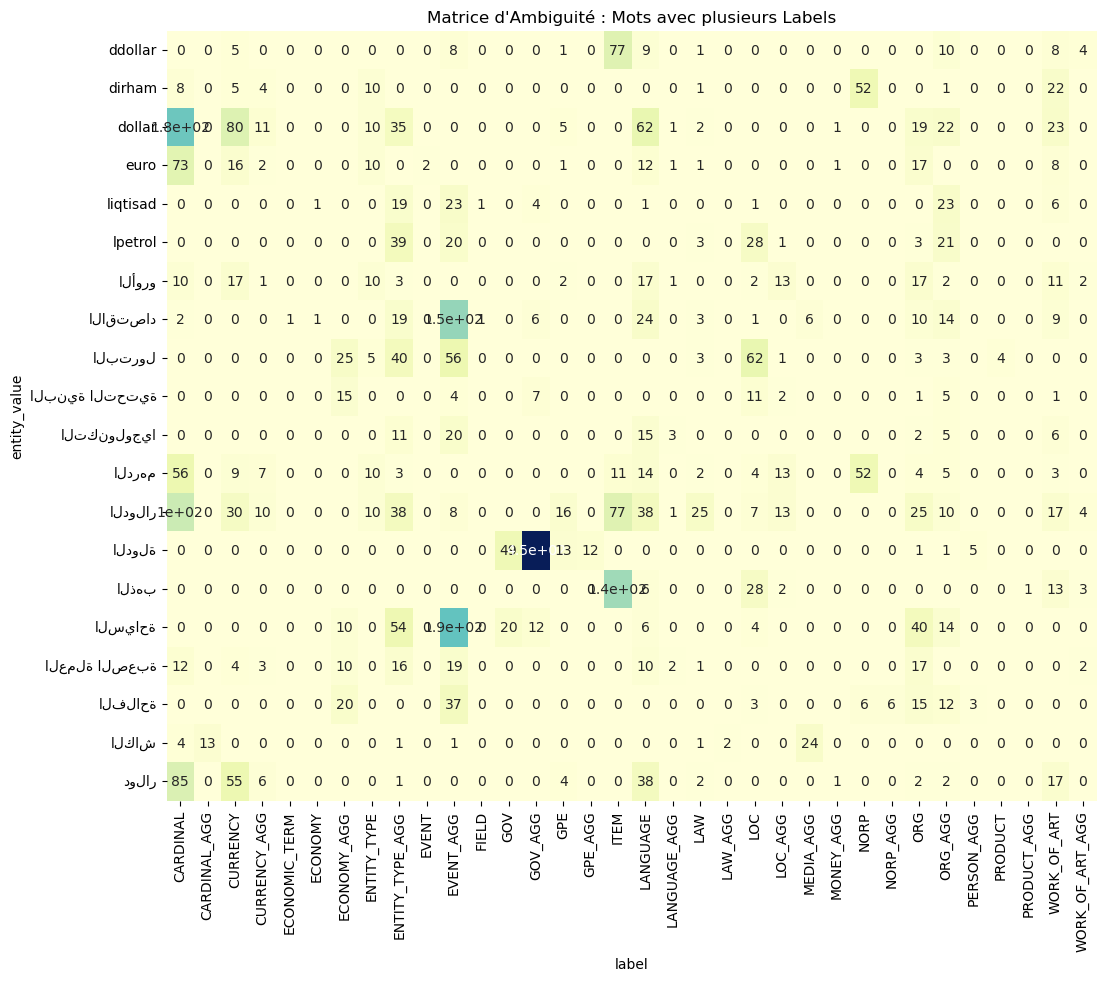

In [14]:
# On cherche les 20 entités les plus fréquentes qui ont plusieurs labels
ambiguity_check = df.groupby('entity_value')['label'].nunique()
ambiguous_words_all = ambiguity_check[ambiguity_check > 1].sort_values(ascending=False).index
ambiguous_words = ambiguity_check[ambiguity_check > 1].sort_values(ascending=False).head(20).index

df_ambig = df[df['entity_value'].isin(ambiguous_words)]
df_ambig_all = df[df['entity_value'].isin(ambiguous_words_all)]
pivot_ambig = pd.crosstab(df_ambig['entity_value'], df_ambig['label'])

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_ambig, annot=True, cmap="YlGnBu", cbar=False)
plt.title('Matrice d\'Ambiguité : Mots avec plusieurs Labels')
plt.show()

In [15]:
pivot_ambig

label,CARDINAL,CARDINAL_AGG,CURRENCY,CURRENCY_AGG,ECONOMIC_TERM,ECONOMY,ECONOMY_AGG,ENTITY_TYPE,ENTITY_TYPE_AGG,EVENT,...,MONEY_AGG,NORP,NORP_AGG,ORG,ORG_AGG,PERSON_AGG,PRODUCT,PRODUCT_AGG,WORK_OF_ART,WORK_OF_ART_AGG
entity_value,,,,,,,,,,,,,,,,,,,,,
ddollar,0,0,5,0,0,0,0,0,0,0,...,0,0,0,0,10,0,0,0,8,4
dirham,8,0,5,4,0,0,0,10,0,0,...,0,52,0,0,1,0,0,0,22,0
dollar,185,0,80,11,0,0,0,10,35,0,...,1,0,0,19,22,0,0,0,23,0
euro,73,0,16,2,0,0,0,10,0,2,...,1,0,0,17,0,0,0,0,8,0
liqtisad,0,0,0,0,0,1,0,0,19,0,...,0,0,0,0,23,0,0,0,6,0
lpetrol,0,0,0,0,0,0,0,0,39,0,...,0,0,0,3,21,0,0,0,0,0
الأورو,10,0,17,1,0,0,0,10,3,0,...,0,0,0,17,2,0,0,0,11,2
الاقتصاد,2,0,0,0,1,1,0,0,19,0,...,0,0,0,10,14,0,0,0,9,0
البترول,0,0,0,0,0,0,25,5,40,0,...,0,0,0,3,3,0,4,0,0,0


In [16]:
pivot_ambig_all = pd.crosstab(df_ambig_all['entity_value'], df_ambig_all['label'])
pivot_ambig_all.head(20)

label,BANK,CARDINAL,CARDINAL_AGG,COUNTRY,CURRENCY,CURRENCY_AGG,DATA,DATE,DATE_AGG,ECONOMIC_TERM,...,ORG_AGG,PERCENT,PERSON,PERSON_AGG,PERSON_AGG_AGG,PRODUCT,PRODUCT_AGG,RESOURCE,WORK_OF_ART,WORK_OF_ART_AGG
entity_value,,,,,,,,,,,,,,,,,,,,,
1,0,70,0,0,0,0,0,12,0,0,...,0,0,0,0,0,0,0,0,0,0
10,0,144,0,0,0,0,0,4,0,0,...,0,0,0,0,0,0,0,0,0,0
10 snin,0,1,0,0,0,0,0,67,0,0,...,0,0,0,0,0,0,0,0,0,0
10 سنين,0,1,0,0,0,0,0,67,0,0,...,0,0,0,0,0,0,0,0,0,0
11,0,31,0,0,0,0,0,4,0,0,...,0,0,0,0,0,0,0,0,0,0
12,0,122,0,0,0,0,0,12,0,0,...,0,0,0,0,0,0,0,0,0,0
123,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13,0,18,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13%,0,138,0,0,0,0,0,0,0,0,...,0,4,0,0,0,0,0,0,0,0


In [17]:
# voir les cardinals dollar,ddolar.. groupby entity_value et label la place de fichier, compter les occurrences
df[df['entity_value'].str.contains('dollar|دولار|درهم|اورو|euro|dirham', case=False, na=False)].groupby(['entity_value', 'label', 'file']).size().reset_index(name='count').head(20)


,entity_value,label,file,count
0,1 dollar,CARDINAL,Darija AI Discussion and Tagging - 169.txt,1
1,1 dollar,CARDINAL,Darija NER Tagging Assistant Workflow - 176.txt,1
2,1 dollar,CARDINAL,Darija NER Tagging_ Tourism & Economy - 170.txt,1
3,1 dollar,CARDINAL,Darija Text Analysis and Tagging - 175.txt,1
4,1 dollar,CARDINAL,Disappearance of Bank Al-Maghrib Governor - 16...,1
5,1 dollar,CARDINAL,Global Politics and Moroccan Economy - 167.txt,1
6,1 dollar,CARDINAL,Moroccan Census_ Cost vs. Benefit - 173.txt,1
7,1 dollar,CARDINAL,Moroccan Darija Financial Advice - 160.txt,1
8,1 dollar,CARDINAL,Moroccan Darija Investment Advice - 159.txt,1
9,1 dollar,CARDINAL,Moroccan Darija NER Tagging Assistant - 172.txt,1


In [19]:
df[df['entity_value'].str.contains('lpetrol', case=False, na=False)].groupby(['entity_value', 'label', 'file']).size().reset_index(name='count').head(50)


,entity_value,label,file,count
0,lboldan lmontija l lpetrol,NORP,ارتفاع أسعار المحروقات في المغرب - 32.txt,1
1,lpetrol,ENTITY_TYPE_AGG,Algeria's 2025 Budget Analysis - 224.txt,2
2,lpetrol,ENTITY_TYPE_AGG,Darija Bitcoin Seizure and Auction - 240.txt,2
3,lpetrol,ENTITY_TYPE_AGG,Darija NER Tagging Assistant - 63.txt,1
4,lpetrol,ENTITY_TYPE_AGG,Darija NER Tagging Assistant Workflow - 229.txt,2
5,lpetrol,ENTITY_TYPE_AGG,Darija NER Tagging Assistant Workflow - 235.txt,2
6,lpetrol,ENTITY_TYPE_AGG,Darija Text Tagging and Rewriting - 61.txt,1
7,lpetrol,ENTITY_TYPE_AGG,Moroccan Car Industry Discussion - 227.txt,2
8,lpetrol,ENTITY_TYPE_AGG,Moroccan Darija Budget Law Analysis - 225.txt,2
9,lpetrol,ENTITY_TYPE_AGG,Moroccan Darija Economic & Social Discussion -...,2
